# ch04

## 4.2

In [4]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

In [3]:
# 设“2”为正确解
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# 例1：“2”的概率最高的情况（0.6）
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
mean_squared_error(np.array(y), np.array(t))

np.float64(0.09750000000000003)

In [4]:
# 例2：“7”的概率最高的情况（0.6）
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
mean_squared_error(np.array(y), np.array(t))

np.float64(0.5975)

In [5]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [6]:
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
cross_entropy_error(np.array(y), np.array(t))

np.float64(0.510825457099338)

In [7]:
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
cross_entropy_error(np.array(y), np.array(t))

np.float64(2.3025840929945454)

In [8]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(normalize=True, one_hot_label=True)

print(x_train.shape) # (60000, 784)
print(t_train.shape) # (60000, 10)

(60000, 784)
(60000, 10)


In [10]:
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

print(x_batch)
print(t_batch)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [11]:
np.random.choice(60000, 10)

array([40200, 12082, 14902, 18442, 29553,  9858, 59865, 14617, 26667,
       39622])

In [14]:
def cross_entropy_error_onehot(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

In [15]:
def cross_entropy_error_index(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

In [18]:
# 示例数据
np.random.seed(42)
batch_size = 3
num_classes = 5

# 模拟模型输出概率（每行和为 1）
y = np.random.rand(batch_size, num_classes)
y = y / y.sum(axis=1, keepdims=True)

# 真实标签（整数索引）
t_int = np.array([0, 2, 4])

# 将整数标签转换为 one-hot
t_onehot = np.eye(num_classes)[t_int]

# 计算损失
loss_onehot = cross_entropy_error_onehot(y, t_onehot)
loss_index = cross_entropy_error_index(y, t_int)

print("预测概率 y:")
print(y)
print("\n整数标签 t_int:", t_int)
print("one-hot 标签 t_onehot:\n", t_onehot)
print("\n使用 one-hot 标签计算的损失:", loss_onehot)
print("使用整数索引标签计算的损失:", loss_index)
print("两者是否相等？", np.allclose(loss_onehot, loss_index))

预测概率 y:
[[0.13319703 0.33810082 0.26031769 0.21289984 0.05548463]
 [0.06528492 0.02430844 0.36250145 0.25157131 0.29633388]
 [0.00928442 0.43746759 0.37546445 0.09577331 0.08201023]]

整数标签 t_int: [0 2 4]
one-hot 标签 t_onehot:
 [[1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]]

使用 one-hot 标签计算的损失: 1.843853891935881
使用整数索引标签计算的损失: 1.843853891935881
两者是否相等？ True


## 4.3

In [1]:
def numerical_diff(f, x):
    h = 1e-4 # 0.0001
    return (f(x+h) - f(x-h)) / (2*h)

In [2]:
def function_1(x):
    return 0.01*x**2 + 0.1*x

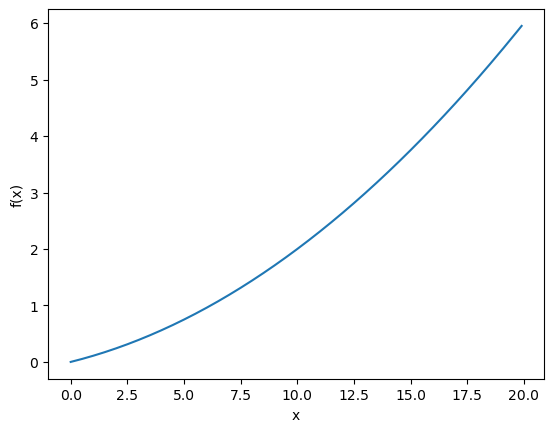

In [5]:
x = np.arange(0.0, 20.0, 0.1) # 以0.1为单位，从0到20的数组x
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

In [7]:
d1 = numerical_diff(function_1, 5)
d2 = numerical_diff(function_1, 10)
print(d1)
print(d2)

0.1999999999990898
0.2999999999986347


## 4.4

In [8]:
def function_2(x):
    # 或者return np.sum(x**2)
    return x[0]**2 + x[1]**2

In [9]:
def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # 生成和x形状相同的数组

    for idx in range(x.size):
        tmp_val = x[idx]
        # f(x+h)的计算
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h)的计算
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 还原值

    return grad

In [11]:
numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [12]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [13]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])

In [14]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x

In [15]:
def function_2(x):
     return x[0]**2 + x[1]**2

In [16]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

In [17]:
# 学习率过大的例子：lr=10.0
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=10.0, step_num=100)

array([-2.58983747e+13, -1.29524862e+12])

In [18]:
# 学习率过小的例子：lr=1e-10
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=1e-10, step_num=100)

array([-2.99999994,  3.99999992])

### simple net

In [24]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class SimpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3) # 用高斯分布进行初始化

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

In [30]:
net = SimpleNet()
print(net.W) # 权重参数

[[-1.87218141 -1.19150967 -1.61485534]
 [ 0.49496995 -0.88563829 -0.06434305]]


In [31]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

[-0.67783589 -1.51198026 -1.02682195]


In [32]:
np.argmax(p) # 最大值的索引

np.int64(0)

In [33]:
t = np.array([0, 0, 1]) # 正确解标签
net.loss(x, t)

np.float64(1.1096274780003916)

In [34]:
def f(W):
     return net.loss(x, t)

In [36]:
dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.28041976  0.12177113 -0.40219089]
 [ 0.42062964  0.18265669 -0.60328633]]


In [41]:
f = lambda w: net.loss(x, t)
dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.28041976  0.12177113 -0.40219089]
 [ 0.42062964  0.18265669 -0.60328633]]
